In [1]:
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.5
Plasticnet version  0.1.14
macOS-15.5-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
base_sim_dir=f"sims-2025-06-09 figs"
if not os.path.exists(base_sim_dir):
    print("new")
    os.mkdir(base_sim_dir)
print(base_sim_dir)


sims-2025-06-09 figs


In [4]:
def default_post(number_of_neurons):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(0,50)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

In [5]:
def deficit(blur=[2.5,-1],noise=[0.1,0.1],rf_size=19,
            eta=2e-6,
           number_of_neurons=10,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,
           total_time=8*day*4,
           save_interval=1*hour):


    print("sigma_c",sigma_c)
    
    im=[]
    for b in blur:
        if b<0:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
        else:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':b},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                   rf_size=rf_size,
                                                sigma_r=0,
                                                sigma_c=0,
                                       verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],rf_size=rf_size,
                                other_channel=pre1,
                                    mu_r=mu_r,mu_c=mu_c,
                                    sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi,
                            )

    return sim,[pre,post],[c]


@ray.remote
def run_one_deficit(params,run=True,overwrite=False):
    import plasticnet as pn
    eta,noise,blur,mu_c,mu_r,sigma_c,sigma_r,number_of_neurons,sfname=(
                                params.eta,
                                params.noise,
                                params.blur,
                                params.mu_c,
                                params.mu_r,
                                params.sigma_c,
                                params.sigma_r,
                                params.number_of_neurons,
                                params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 eta=eta,
                 noise=noise,blur=blur,
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,) 


    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [6]:
print("Base Image File:",base_image_file)
imfname=pi5.filtered_images(
                            base_image_file,
                            )
image_data=pi5.asdf_load_images(imfname)


Base Image File: asdf/bbsk081604_all_scale2.asdf
Using cache_images/cache_images_3022abd002cdb9148ddc6391a446d321.asdf from cache.

Using cache_images/cache_images_3022abd002cdb9148ddc6391a446d321.asdf from cache.Using cache_images/cache_images_868bab66e715029d15e53164634c737c.asdf from cache.Using cache_images/cache_images_cc5c6b62e4aceceee832ad865ff445c1.asdf from cache.Using cache_images/cache_images_e21ffa729c2ccf62ed916bf2df1788c4.asdf from cache.

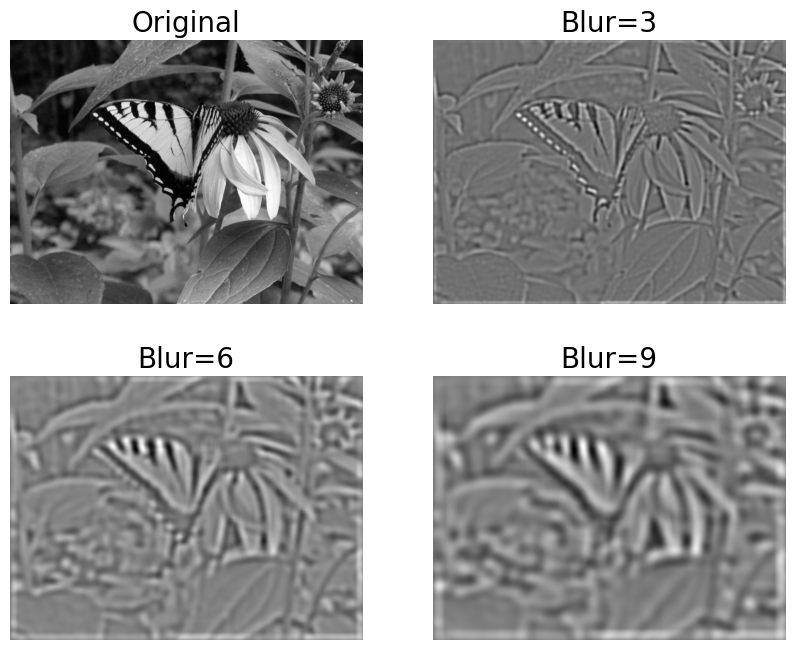

In [7]:
blur_vals=[-1,3,6,9]

for b,blur in enumerate(blur_vals):
    if blur<0:
        imfname=pi5.filtered_images(base_image_file,
                            verbose=True,
                            )
    else:
        imfname=pi5.filtered_images(base_image_file,
                            {'type':'blur','size':blur},
                            verbose=True,
                            )

    image_data=pi5.asdf_load_images(imfname)        
    im=image_data['im'][5]*image_data['im_scale_shift'][0]+image_data['im_scale_shift'][1]

    subplot(2,2,b+1)
    imshow(im,cmap=cm.gray)
    grid(False)
    axis('off')
    if blur>0:
        title(f'Blur={blur}')
    else:
        title('Original')

In [8]:
number_of_neurons=12
eta=1e-6
number_of_processes=8
ray.init(num_cpus=number_of_processes,ignore_reinit_error=True)

2025-06-25 06:50:50,048	INFO worker.py:1888 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.46.0


(pid=22722) Splikes version  0.1.5
(pid=22722) Plasticnet version  0.1.14
(run_one_continuous_fix pid=22722) sigma_c 0
(run_one_continuous_fix pid=22722) [
(run_one_continuous_fix pid=22722) .
(run_one_continuous_fix pid=22722) .] Sequence Time Elapsed...16 m, 44.53 s
(run_one_continuous_fix pid=22722) sigma_c 7
(run_one_continuous_fix pid=22722) [
(run_one_continuous_fix pid=22722) .
(run_one_continuous_fix pid=22722) .] Sequence Time Elapsed...16 m, 40.86 s
(run_one_continuous_fix pid=22722) sigma_c 7
(run_one_continuous_fix pid=22722) [
(run_one_continuous_fix pid=22722) .
(run_one_continuous_fix pid=22722) .] Sequence Time Elapsed...16 m, 39.70 s
(run_one_continuous_fix pid=22722) sigma_c 7
(run_one_continuous_fix pid=22722) [
(run_one_continuous_fix pid=22722) .
(run_one_continuous_fix pid=22722) .] Sequence Time Elapsed...16 m, 54.65 s
(run_one_continuous_fix pid=22722) sigma_c 2
(run_one_continuous_fix pid=22722) [
(run_one_continuous_fix pid=22722) .
(pid=22715) Splikes version

(raylet) [2025-06-25 09:11:38,078 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 185.892 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:11:48,166 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 184.888 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:11:58,254 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 184.886 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:12:08,341 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 184.877 GB; capacity: 3721.87 GB. Object creation wil

(run_one_continuous_fix pid=22715) .] Sequence Time Elapsed...17 m, 25.77 s


(raylet) [2025-06-25 09:15:40,169 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 178.81 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:15:50,264 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 178.635 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:16:00,350 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 178.635 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:16:10,431 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 177.873 GB; capacity: 3721.87 GB. Object creation will

(run_one_deficit pid=22715) sigma_c 2
(run_one_deficit pid=22715) [


(raylet) [2025-06-25 09:37:30,947 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 154.018 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:37:41,029 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 154.018 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:37:51,113 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 154.018 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:38:01,201 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 154.019 GB; capacity: 3721.87 GB. Object creation wil

(run_one_deficit pid=22715) .] Sequence Time Elapsed...4 m, 46.55 s


(raylet) [2025-06-25 09:42:23,361 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 153.831 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:42:33,440 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 153.831 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:42:43,515 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 152.985 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-25 09:42:53,596 E 22711 9462327] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-25_06-50-49_002101_22704 is over 95% full, available space: 152.985 GB; capacity: 3721.87 GB. Object creation wil

## Normal development

In [9]:
p=Struct()
p.number_of_neurons=number_of_neurons
p.mu_c=0
p.sigma_c=0
p.mu_r=0
p.sigma_r=0
p.blur=[-1,-1]
p.sfname=base_sim_dir+f"/normal mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"
p.eta=2e-6

p.noise=(.1,.1)


In [10]:
if not os.path.exists(p.sfname):
    print("Running normal development")
    results = [run_one_deficit.remote(p,overwrite=True)]
    sfnames=ray.get(results)
else:
    sfnames=[p.sfname]

In [11]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

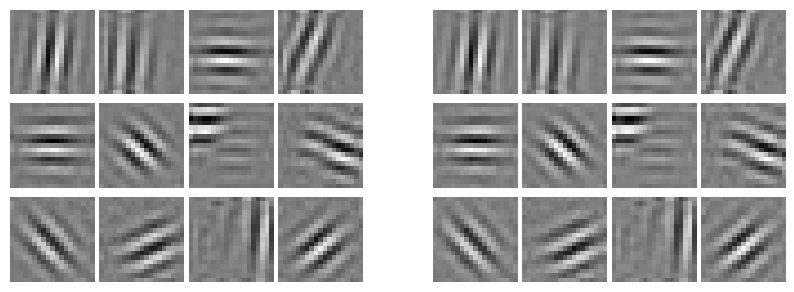

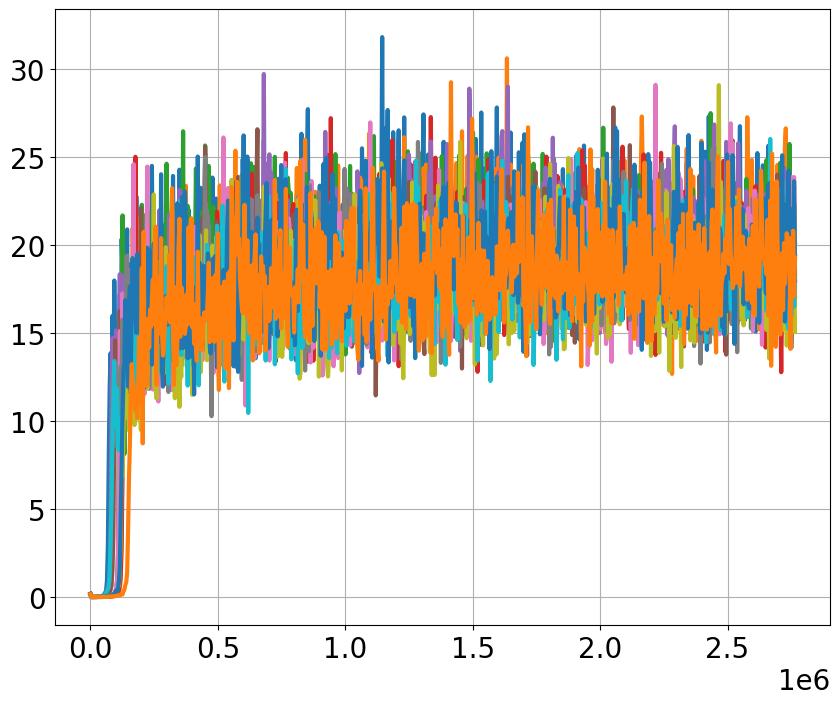

In [12]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [13]:
wim=R.weight_image(R.W[-1,::])
vmin,vmax=wim.min(),wim.max()
wim.shape

(12, 2, 19, 19)

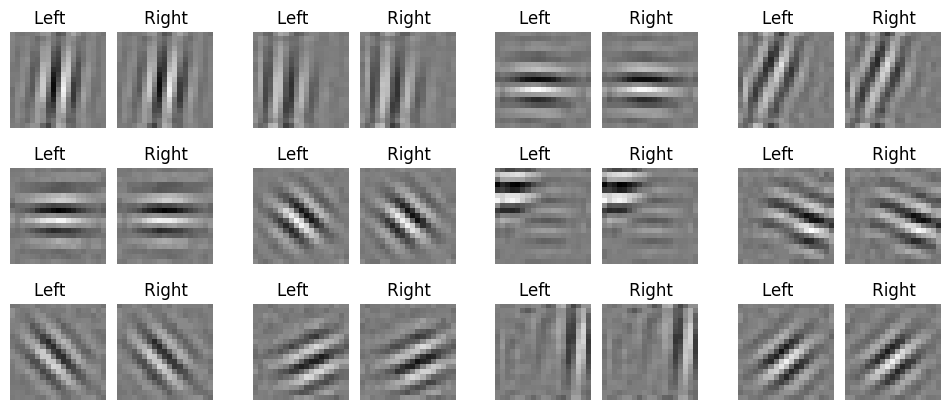

In [14]:
figure(figsize=(12,5))
for i in range(12):
    subplot(3,4,i+1)

    im=np.hstack((wim[i,0,:,:],vmax*ones((wim.shape[-1],2)),wim[i,1,:,:]))
    
    imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
    grid(None)
    title('Left               Right',size=12)
    axis('off')

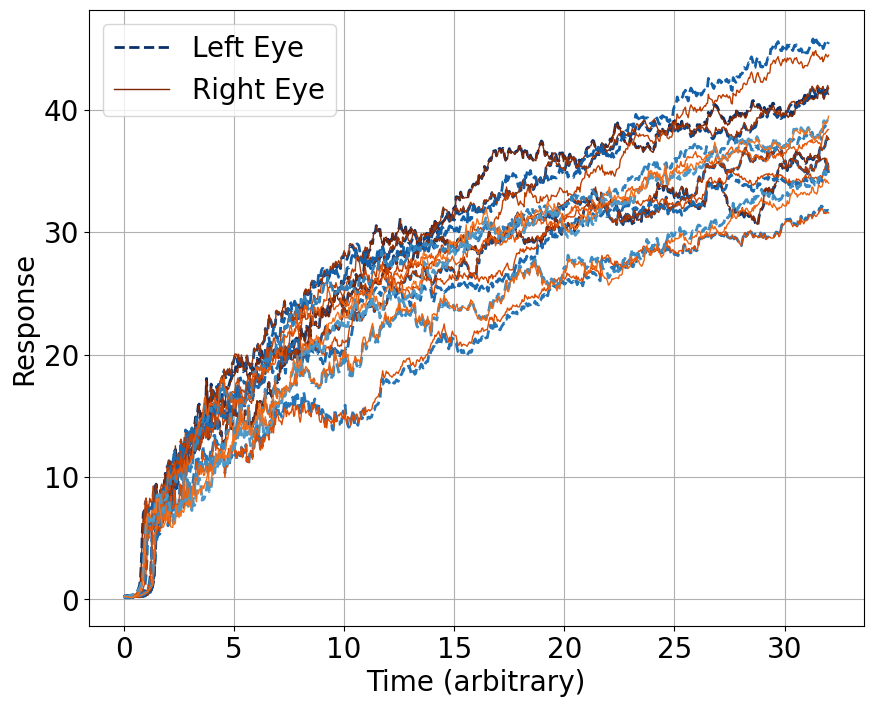

In [15]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

for n in range(10):

    if n==0:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]),label='Left Eye');
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]),label='Right Eye');
    else:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]));
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]));

ylabel('Response')
xlabel('Time (arbitrary)')
legend()

Text(0.5, 0, 'Time (arbitrary)')

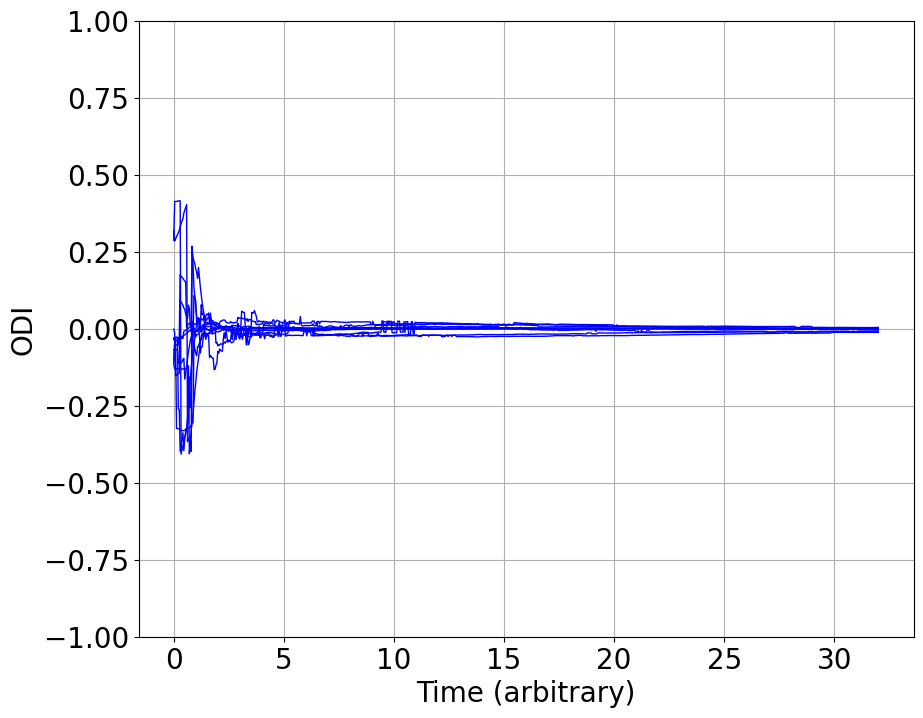

In [16]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

plot(R.t/day,R.ODI[:,:10],'b-',lw=1);

gca().set_ylim([-1,1])
ylim=gca().get_ylim()
#vlines(R.sequence_times[1][0]/day,*ylim)

ylabel('ODI')
xlabel('Time (arbitrary)')

In [17]:
p=Struct()
p.number_of_neurons=number_of_neurons
p.mu_c=7
p.sigma_c=7
p.mu_r=0
p.sigma_r=0
p.blur=[-1,-1]
p.sfname=base_sim_dir+f"/normal mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"
p.eta=2e-6

p.noise=(.1,.1)


In [18]:
if not os.path.exists(p.sfname):
    print("Running normal development")
    results = [run_one_deficit.remote(p,overwrite=True)]
    sfnames=ray.get(results)
else:
    sfnames=[p.sfname]

In [19]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

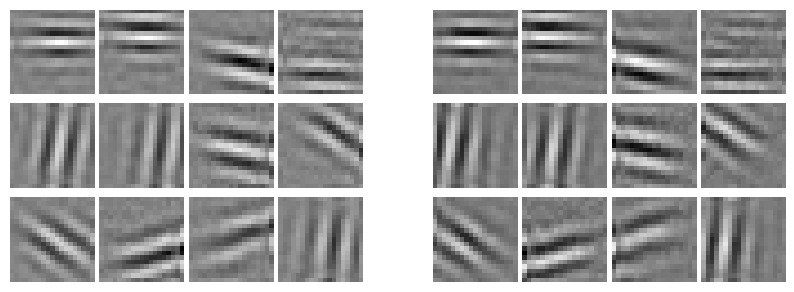

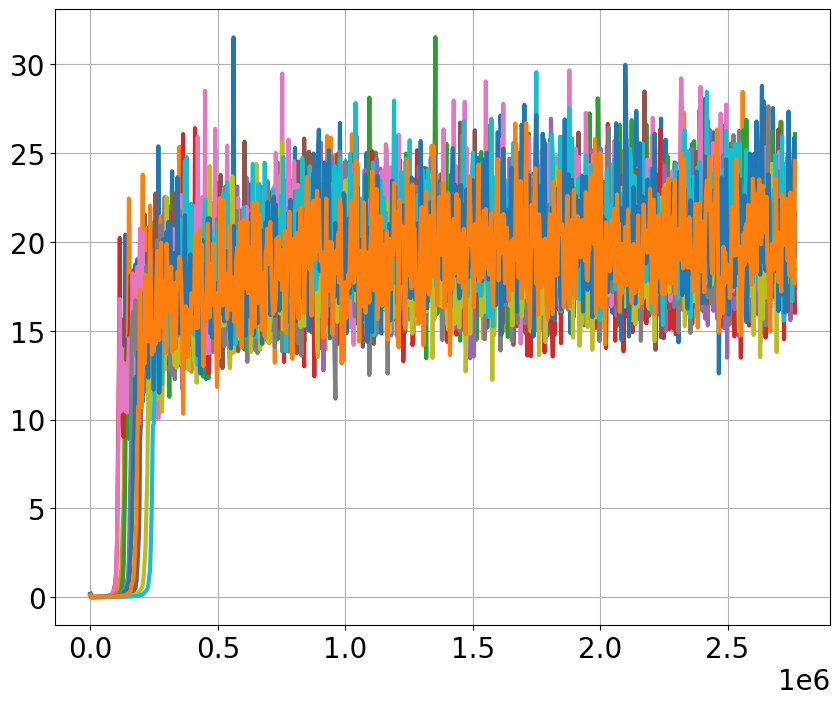

In [20]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [21]:
wim=R.weight_image(R.W[-1,::])
vmin,vmax=wim.min(),wim.max()
wim.shape

(12, 2, 19, 19)

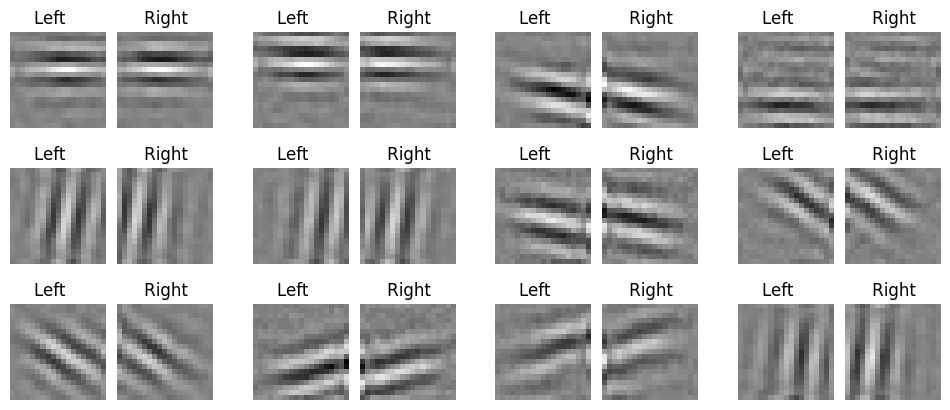

In [22]:
figure(figsize=(12,5))
for i in range(12):
    subplot(3,4,i+1)

    im=np.hstack((wim[i,0,:,:],vmax*ones((wim.shape[-1],2)),wim[i,1,:,:]))
    
    imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
    grid(None)
    title('Left               Right',size=12)
    axis('off')

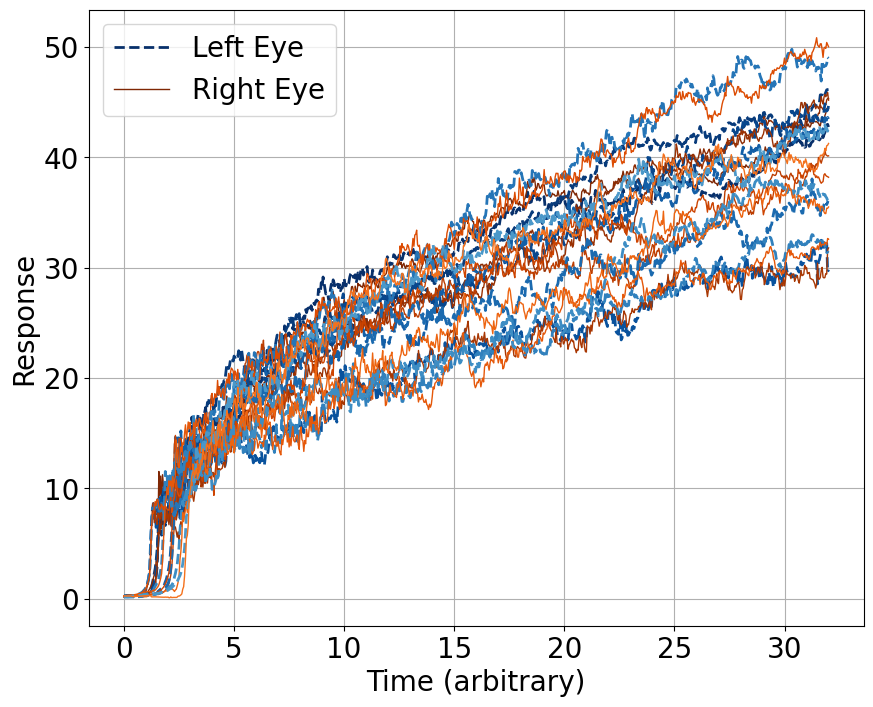

In [23]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

for n in range(10):

    if n==0:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]),label='Left Eye');
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]),label='Right Eye');
    else:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]));
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]));

ylabel('Response')
xlabel('Time (arbitrary)')
legend()

Text(0.5, 0, 'Time (arbitrary)')

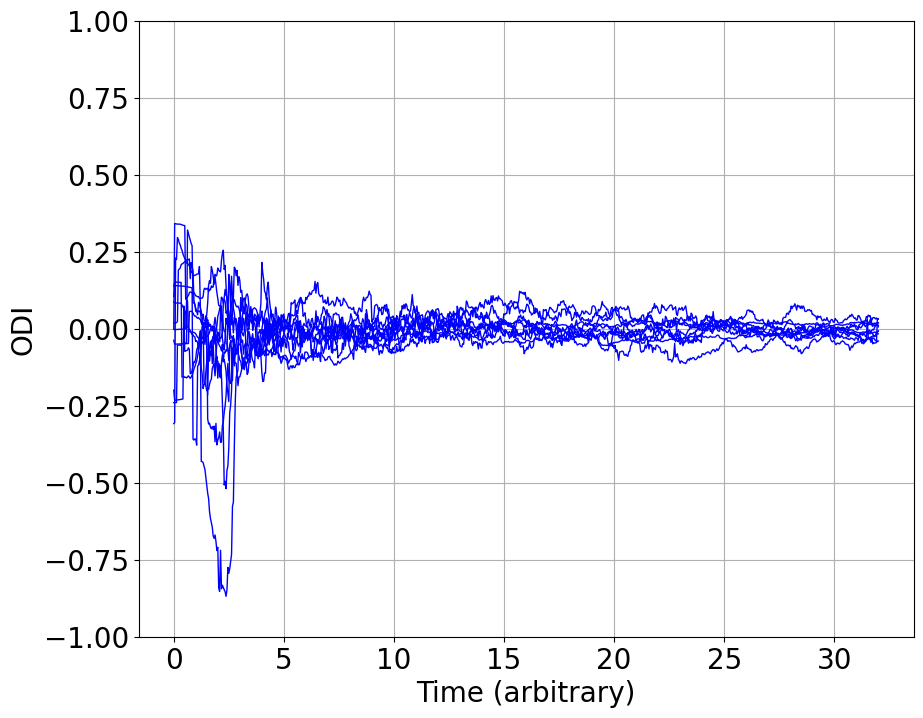

In [24]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

plot(R.t/day,R.ODI[:,:10],'b-',lw=1);

gca().set_ylim([-1,1])
ylim=gca().get_ylim()
#vlines(R.sequence_times[1][0]/day,*ylim)

ylabel('ODI')
xlabel('Time (arbitrary)')

## Example deficit

In [25]:
p=Struct()
p.number_of_neurons=number_of_neurons
p.mu_c=0
p.sigma_c=0
p.mu_r=0
p.sigma_r=0
p.blur=[2,-1]
p.sfname=base_sim_dir+f"/deficit mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"
p.eta=2e-6

p.noise=(.1,.1)


In [26]:
if not os.path.exists(p.sfname):
    print("Running deficit development")
    results = [run_one_deficit.remote(p,overwrite=True)]
    sfnames=ray.get(results)
else:
    sfnames=[p.sfname]

In [27]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

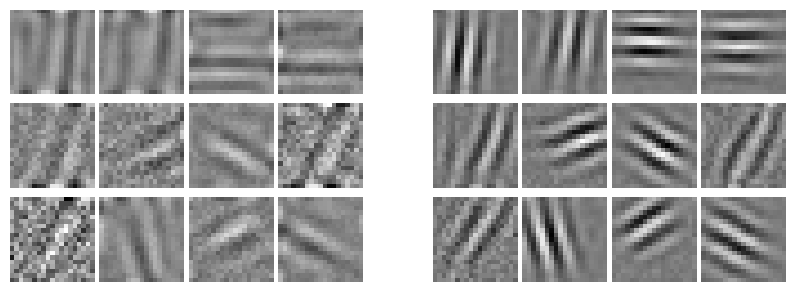

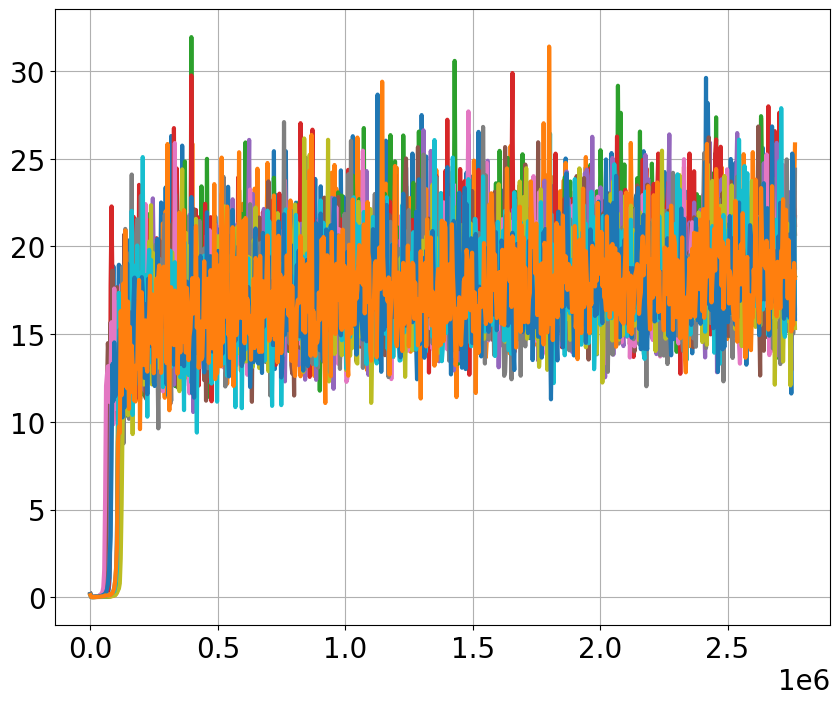

In [28]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [29]:
wim=R.weight_image(R.W[-1,::])
vmin,vmax=wim.min(),wim.max()
wim.shape

(12, 2, 19, 19)

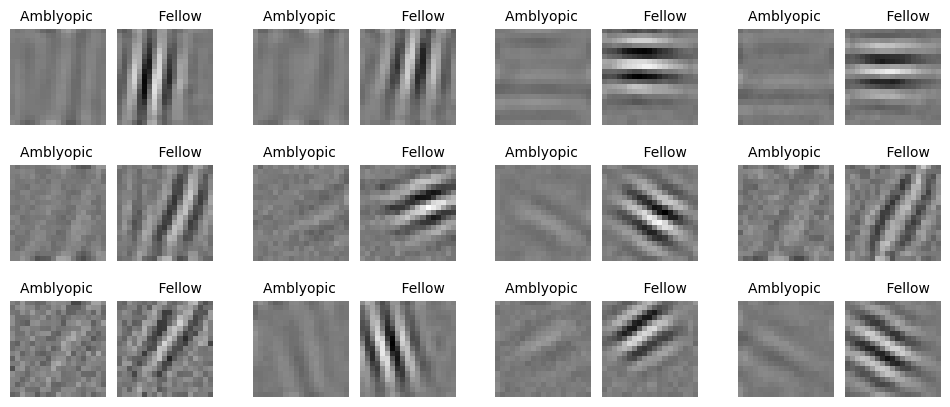

In [30]:
figure(figsize=(12,5))
for i in range(12):
    subplot(3,4,i+1)

    im=np.hstack((wim[i,0,:,:],vmax*ones((wim.shape[-1],2)),wim[i,1,:,:]))
    
    imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
    grid(None)
    title('Amblyopic               Fellow',size=10)
    axis('off')

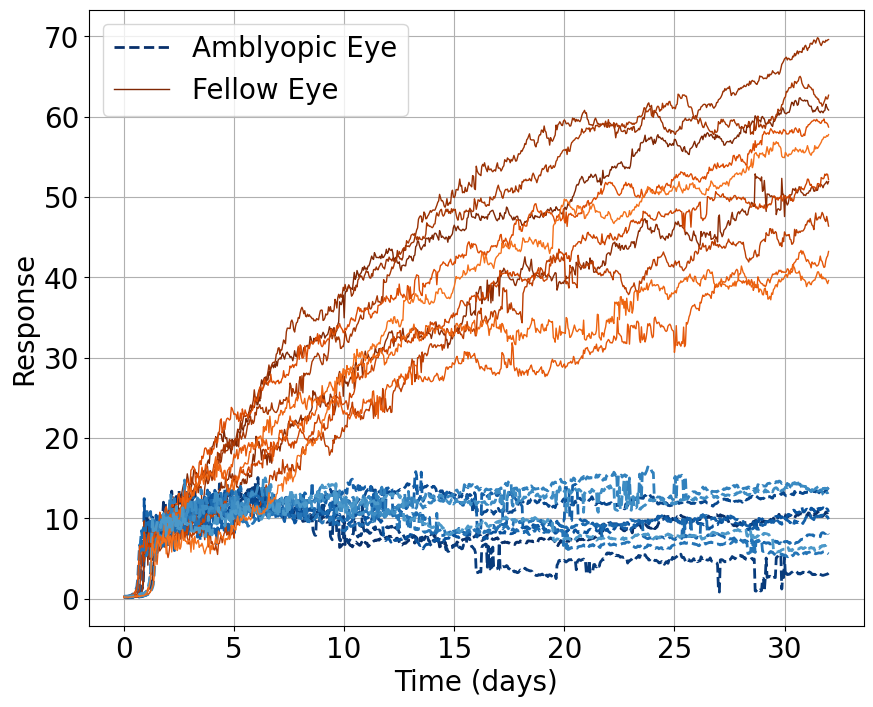

In [31]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

for n in range(10):

    if n==0:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]),label='Amblyopic Eye');
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]),label='Fellow Eye');
    else:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]));
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]));

ylabel('Response')
xlabel('Time (days)')
legend()

Text(0.5, 0, 'Time (arbitrary)')

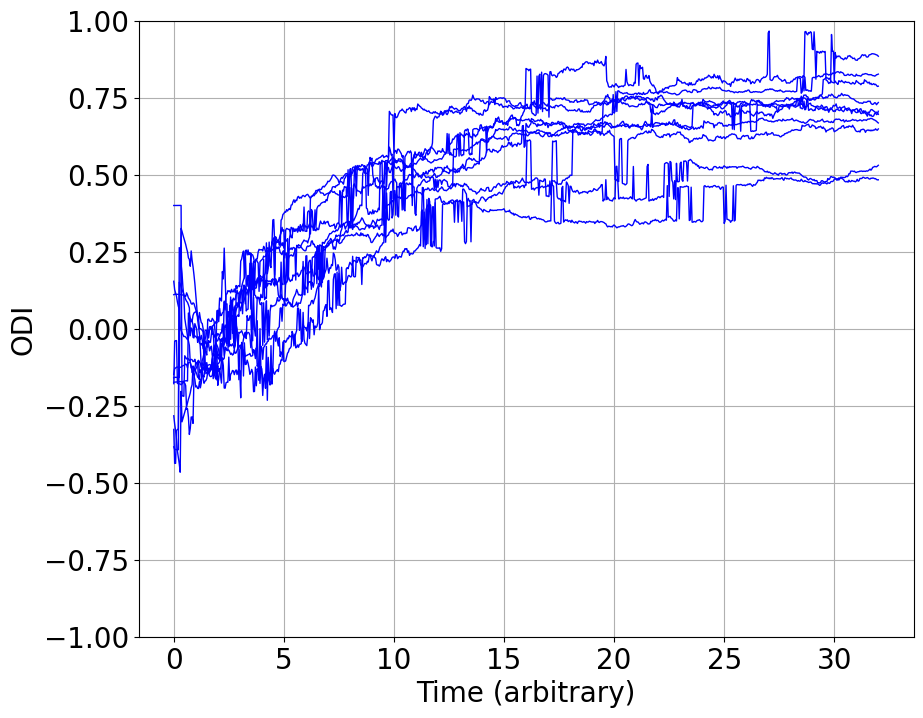

In [32]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

plot(R.t/day,R.ODI[:,:10],'b-',lw=1);

gca().set_ylim([-1,1])
ylim=gca().get_ylim()
#vlines(R.sequence_times[1][0]/day,*ylim)

ylabel('ODI')
xlabel('Time (arbitrary)')

In [90]:
p=Struct()
p.number_of_neurons=number_of_neurons
p.mu_c=7.5
p.sigma_c=2
p.mu_r=0
p.sigma_r=0
p.blur=[2,-1]
p.sfname=base_sim_dir+f"/deficit mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"
p.eta=2e-6

p.noise=(.1,.1)


In [91]:
if not os.path.exists(p.sfname):
    print("Running deficit development")
    results = [run_one_deficit.remote(p,overwrite=True)]
    sfnames=ray.get(results)
else:
    sfnames=[p.sfname]

Running deficit development


In [92]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

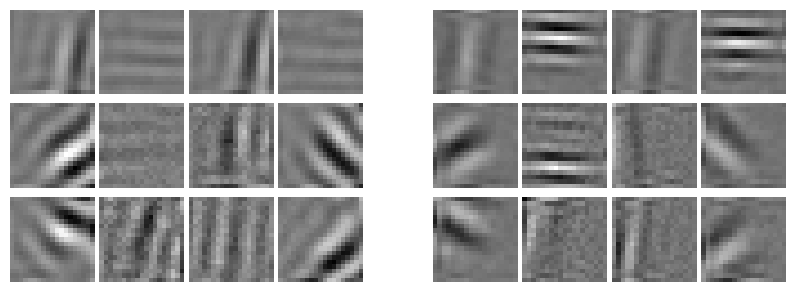

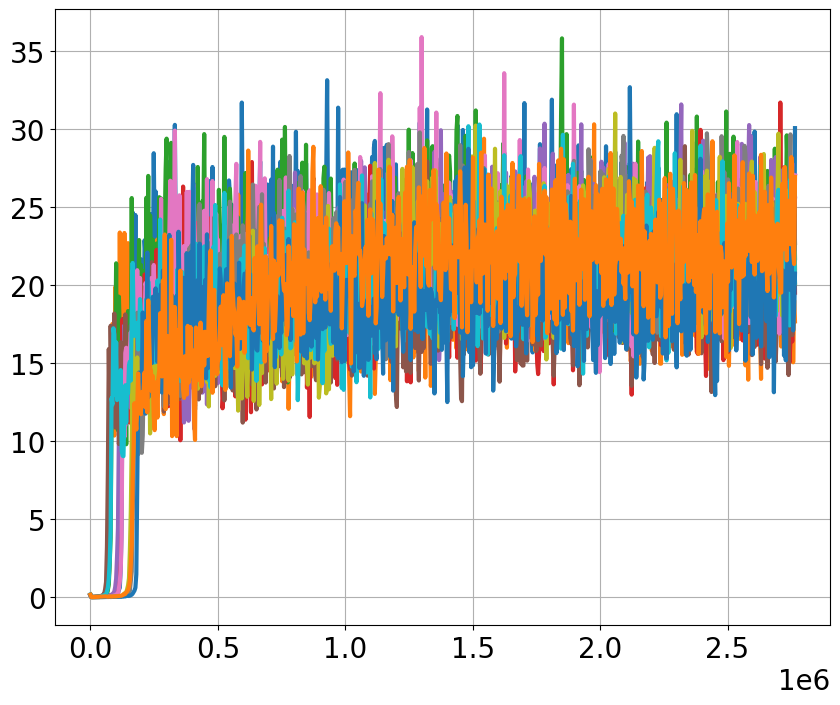

In [93]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [94]:
wim=R.weight_image(R.W[-1,::])
vmin,vmax=wim.min(),wim.max()
wim.shape

(12, 2, 19, 19)

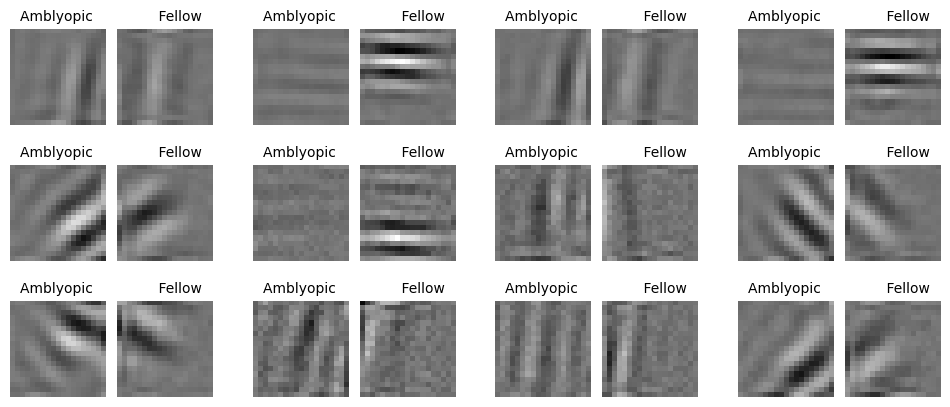

In [95]:
figure(figsize=(12,5))
for i in range(12):
    subplot(3,4,i+1)

    im=np.hstack((wim[i,0,:,:],vmax*ones((wim.shape[-1],2)),wim[i,1,:,:]))
    
    imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
    grid(None)
    title('Amblyopic               Fellow',size=10)
    axis('off')

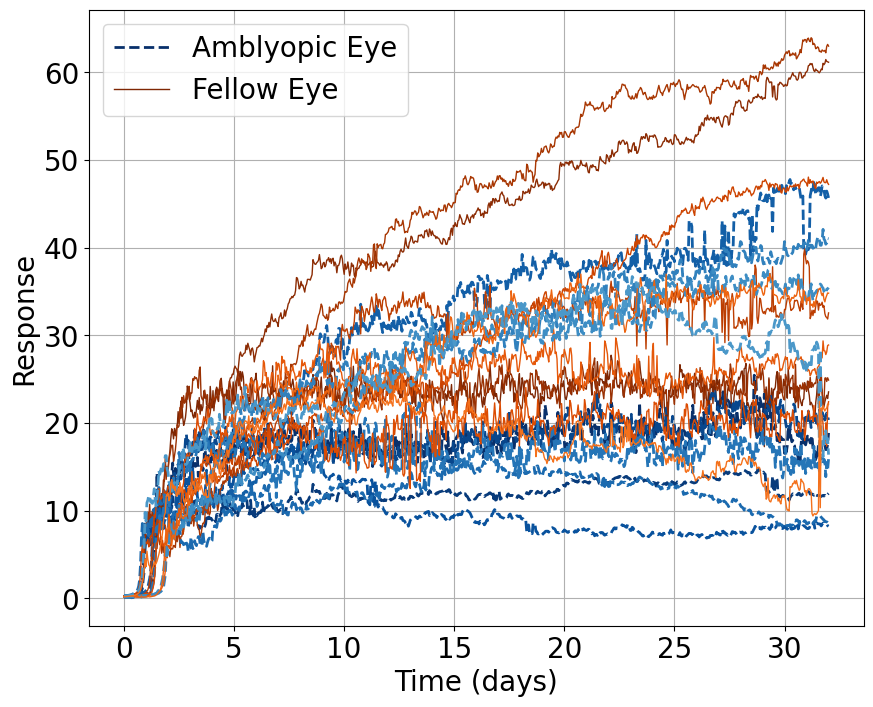

In [96]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

for n in range(10):

    if n==0:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]),label='Amblyopic Eye');
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]),label='Fellow Eye');
    else:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]));
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]));

ylabel('Response')
xlabel('Time (days)')
legend()

Text(0.5, 0, 'Time (arbitrary)')

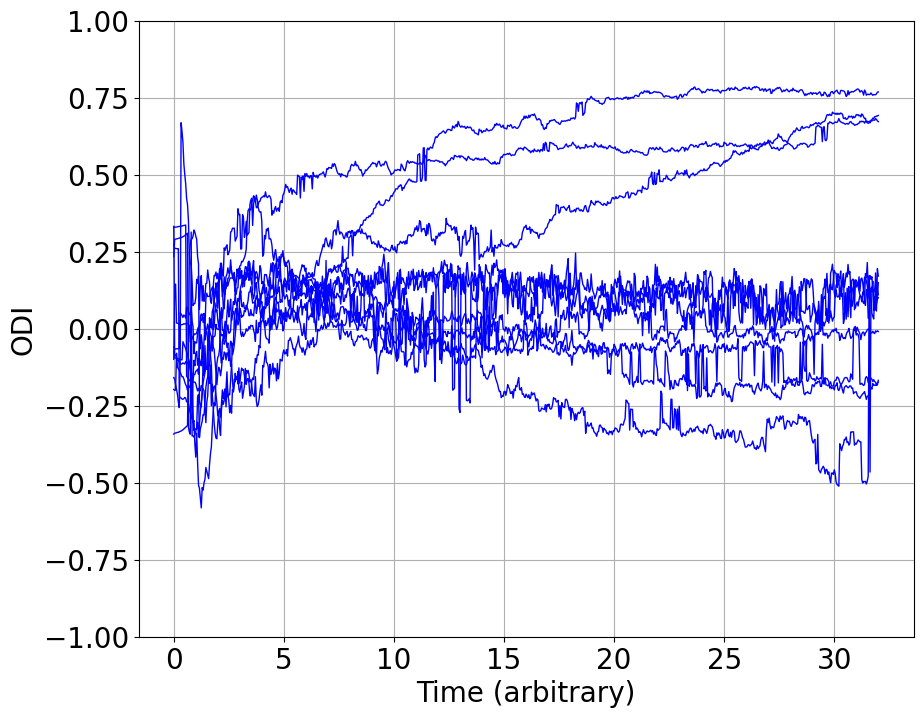

In [97]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

plot(R.t/day,R.ODI[:,:10],'b-',lw=1);

gca().set_ylim([-1,1])
ylim=gca().get_ylim()
#vlines(R.sequence_times[1][0]/day,*ylim)

ylabel('ODI')
xlabel('Time (arbitrary)')

# above here rerun

## Fix

In [41]:
def fix(noise=[0.1,0.1],rf_size=19,
           number_of_neurons=10,
           total_time=8*day,
           save_interval=1*hour,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,        
           eta=2e-6):
    
    
    im=[]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},   
                        verbose=False,
                        )
        ]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},
                        verbose=False,
                        )
        ]
                     
    
    
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                        rf_size=rf_size,
                                        sigma_r=0,
                                        sigma_c=0,
                                        verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],
                                       rf_size=rf_size,
                                       other_channel=pre1,
                                       mu_r=mu_r,mu_c=mu_c,
                                       sigma_r=sigma_r,sigma_c=sigma_c,
                                       verbose=False)
    
    


    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    save_interval=save_interval

    sim=pn.simulation(total_time)

    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi)

    return sim,[pre,post],[c]

@ray.remote
def run_one_continuous_fix(params,run=True,overwrite=False):
    import plasticnet as pn
    eta,noise,mu_c,mu_r,sigma_c,sigma_r,number_of_neurons,blur,total_times,sfname=(
                                params.eta,
                                params.noise,
                                params.mu_c,
                                params.mu_r,
                                params.sigma_c,
                                params.sigma_r,
                                params.number_of_neurons,
                                params.blur,
                                params.total_time,
                                params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,
                 total_time=total_times[0],
                blur=blur) 

    seq+=fix(
             save_interval=20*minute,number_of_neurons=params.number_of_neurons,
             eta=eta,noise=noise,mu_c=mu_c,sigma_c=sigma_c,
                 total_time=total_times[1],
             mu_r=mu_r,sigma_r=sigma_r)

    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [42]:
func=run_one_continuous_fix

p=Struct()
p.eta=eta
p.number_of_neurons=number_of_neurons
p.mu_c=0
p.sigma_c=0
p.mu_r=0
p.sigma_r=0
p.blur=[2,-1]
p.noise=(.1,.1)
p.eta=2e-6
p.total_time=[8*day*4,8*day*8]
p.sfname=base_sim_dir+f"/fix mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"
print(p.sfname)


sims-2025-06-09 figs/fix mu_c=0 sigma_c=0 blur=2.asdf


In [43]:
overwrite=True

In [44]:
if not os.path.exists(p.sfname) or overwrite:
    print("Running deficit/fix development")
    results = [func.remote(p,overwrite=True)]
    sfnames=ray.get(results)
else:
    sfnames=[p.sfname]

Running deficit/fix development


In [45]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

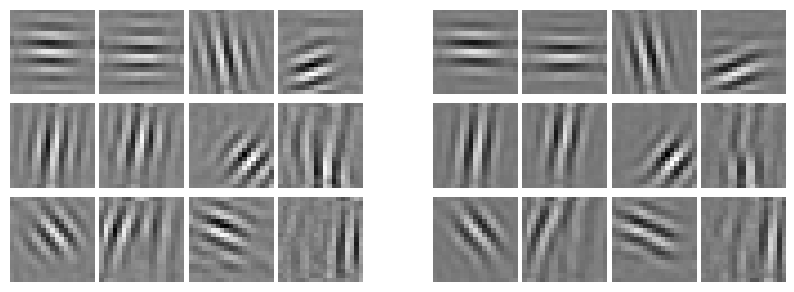

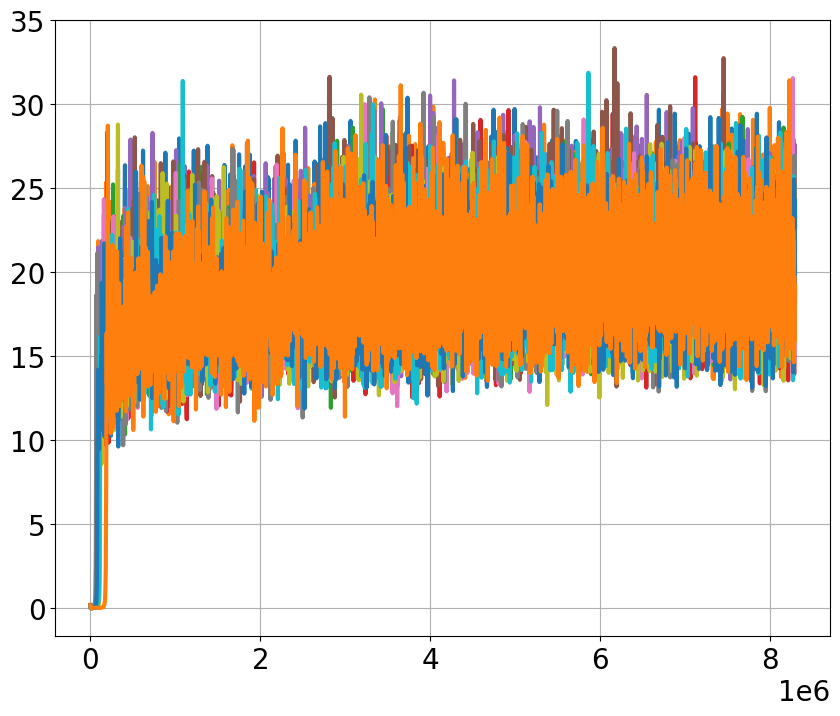

In [46]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [47]:
wim=R.weight_image(R.W[-1,::])
vmin,vmax=wim.min(),wim.max()
wim.shape

(12, 2, 19, 19)

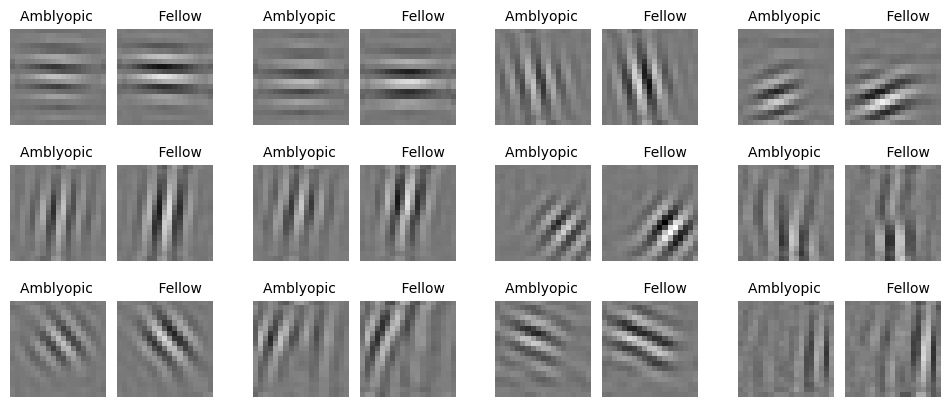

In [48]:
figure(figsize=(12,5))
for i in range(12):
    subplot(3,4,i+1)

    im=np.hstack((wim[i,0,:,:],vmax*ones((wim.shape[-1],2)),wim[i,1,:,:]))
    
    imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
    grid(None)
    title('Amblyopic               Fellow',size=10)
    axis('off')

(0.0, 76.52287549489976)

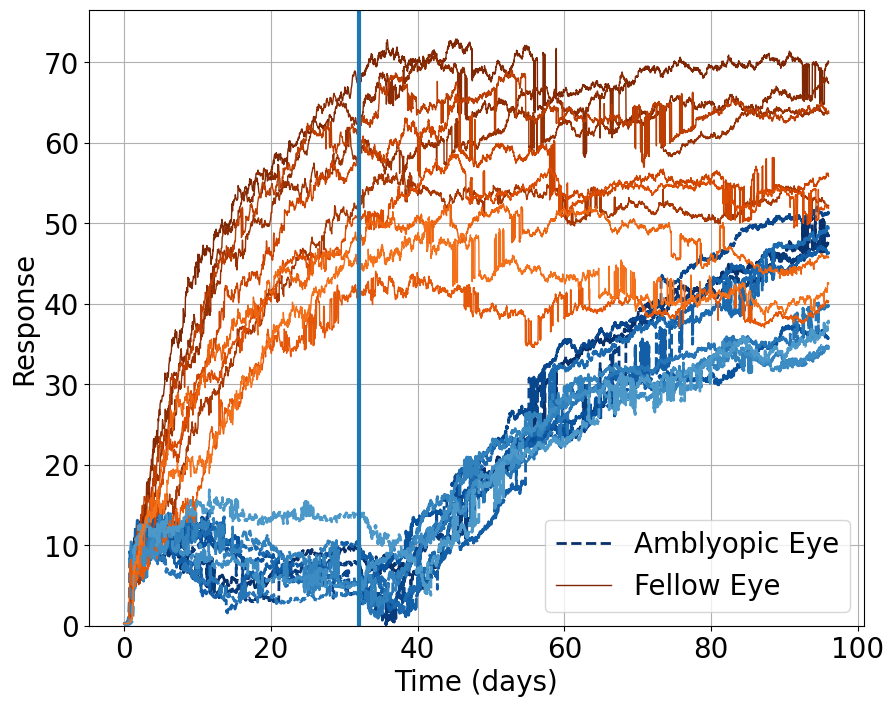

In [49]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

for n in range(10):

    if n==0:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]),label='Amblyopic Eye');
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]),label='Fellow Eye');
    else:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]));
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]));


ylabel('Response')
xlabel('Time (days)')
legend()

ylim=gca().get_ylim()
ylim=[0,ylim[1]]
vlines(R.sequence_times[1][0]/day,*ylim)
gca().set_ylim(ylim)


Text(0.5, 0, 'Time (days)')

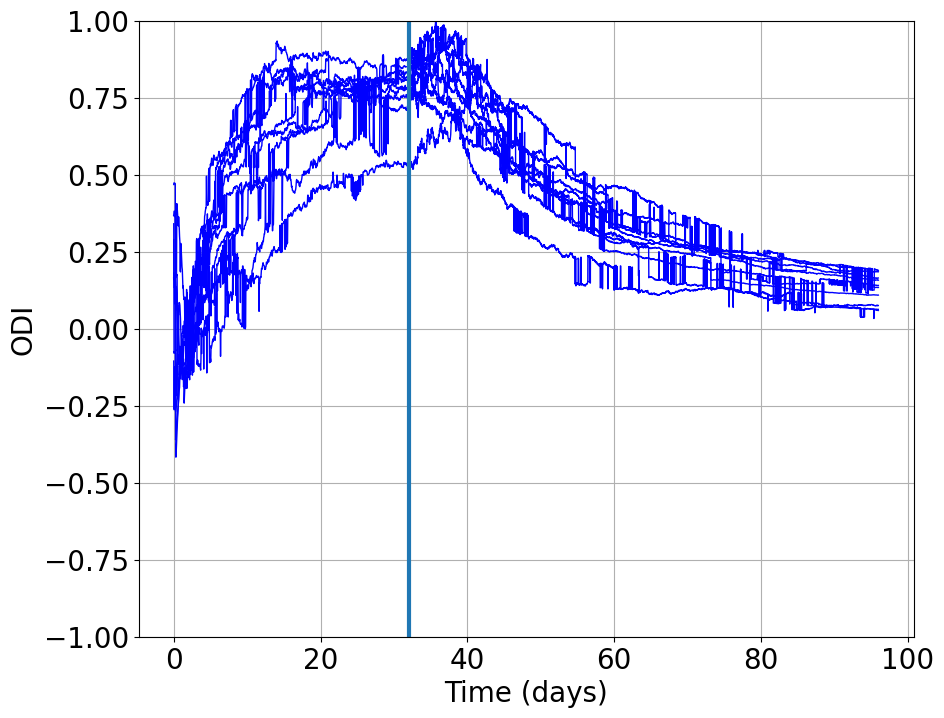

In [50]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

plot(R.t/day,R.ODI[:,:10],'b-',lw=1);

gca().set_ylim([-1,1])
ylim=gca().get_ylim()
vlines(R.sequence_times[1][0]/day,*ylim)

ylabel('ODI')
xlabel('Time (days)')

In [51]:
func=run_one_continuous_fix

p=Struct()
p.eta=eta
p.number_of_neurons=number_of_neurons
p.mu_c=7
p.sigma_c=7
p.mu_r=0
p.sigma_r=0
p.blur=[2,-1]
p.noise=(.1,.1)
p.eta=2e-6
p.total_time=[8*day*4,8*day*8]
p.sfname=base_sim_dir+f"/fix mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"
print(p.sfname)


sims-2025-06-09 figs/fix mu_c=7 sigma_c=7 blur=2.asdf


In [52]:
overwrite=True

In [53]:
if not os.path.exists(p.sfname) or overwrite:
    print("Running deficit/fix development")
    results = [func.remote(p,overwrite=True)]
    sfnames=ray.get(results)
else:
    sfnames=[p.sfname]

Running deficit/fix development


In [54]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

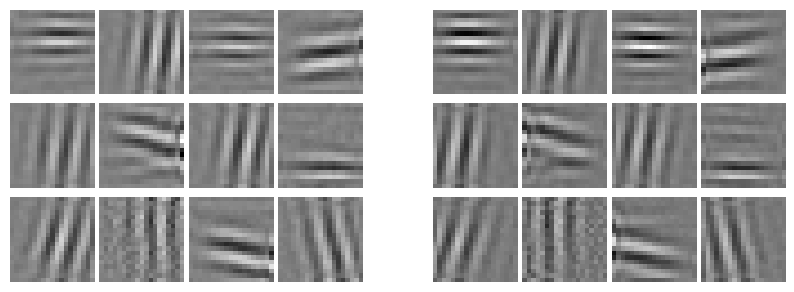

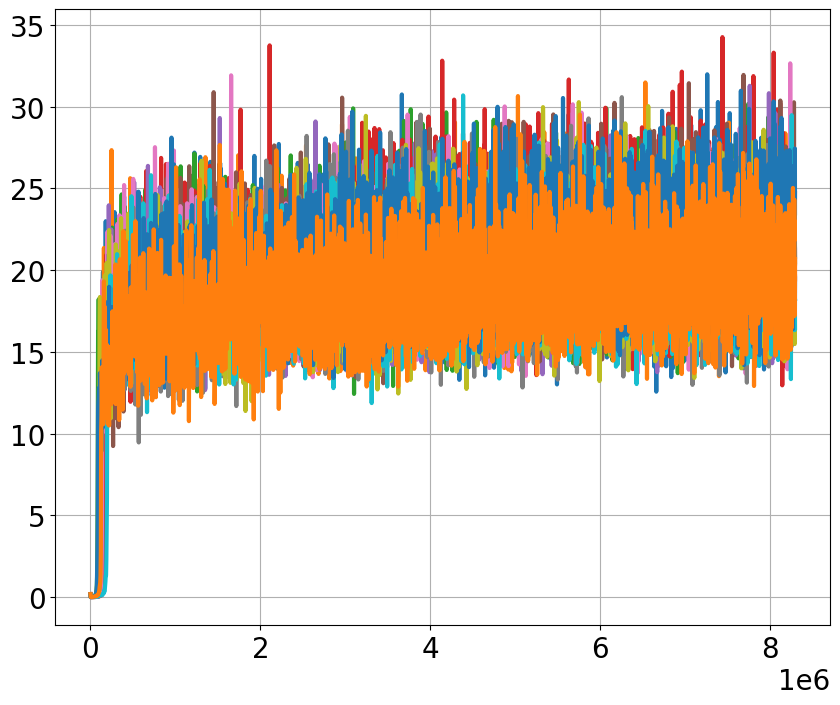

In [55]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [56]:
wim=R.weight_image(R.W[-1,::])
vmin,vmax=wim.min(),wim.max()
wim.shape

(12, 2, 19, 19)

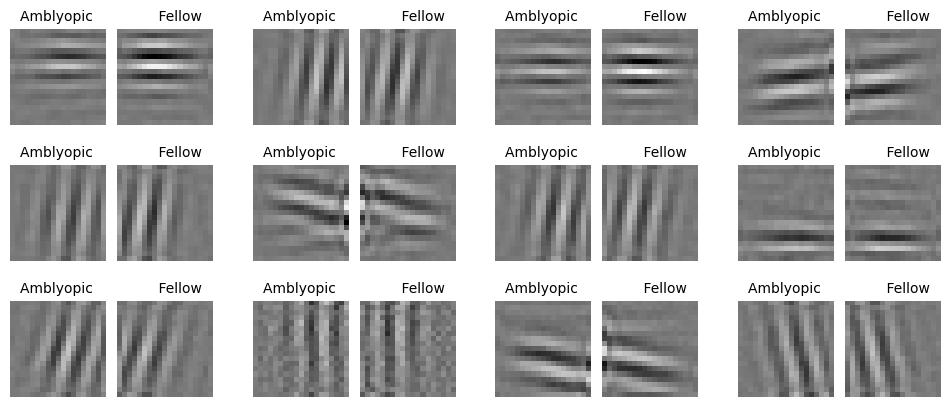

In [57]:
figure(figsize=(12,5))
for i in range(12):
    subplot(3,4,i+1)

    im=np.hstack((wim[i,0,:,:],vmax*ones((wim.shape[-1],2)),wim[i,1,:,:]))
    
    imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
    grid(None)
    title('Amblyopic               Fellow',size=10)
    axis('off')

(0.0, 77.48136556349363)

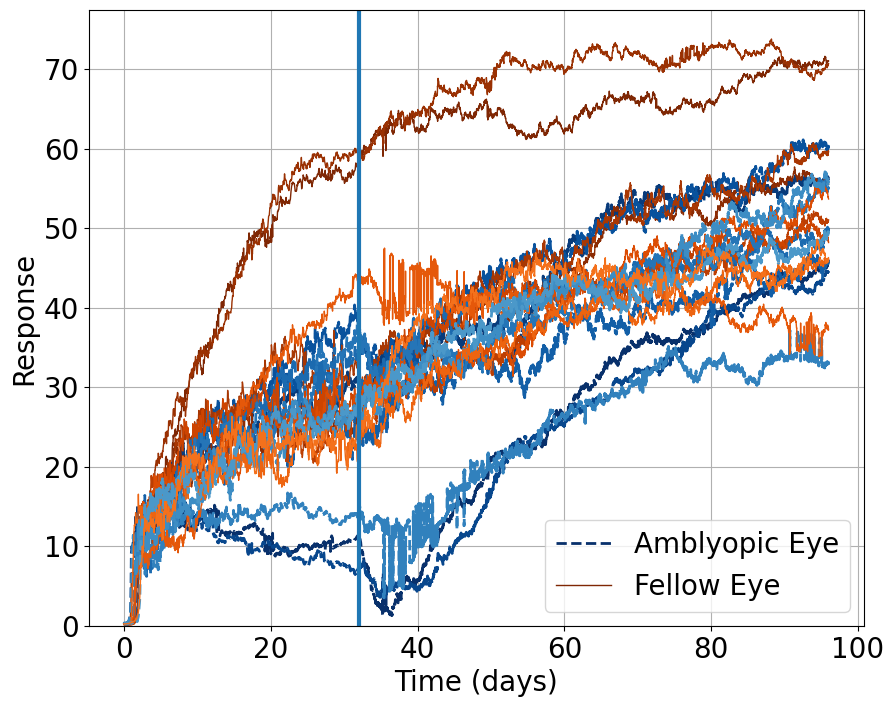

In [58]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

for n in range(10):

    if n==0:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]),label='Amblyopic Eye');
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]),label='Fellow Eye');
    else:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]));
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]));


ylabel('Response')
xlabel('Time (days)')
legend()

ylim=gca().get_ylim()
ylim=[0,ylim[1]]
vlines(R.sequence_times[1][0]/day,*ylim)
gca().set_ylim(ylim)


Text(0.5, 0, 'Time (days)')

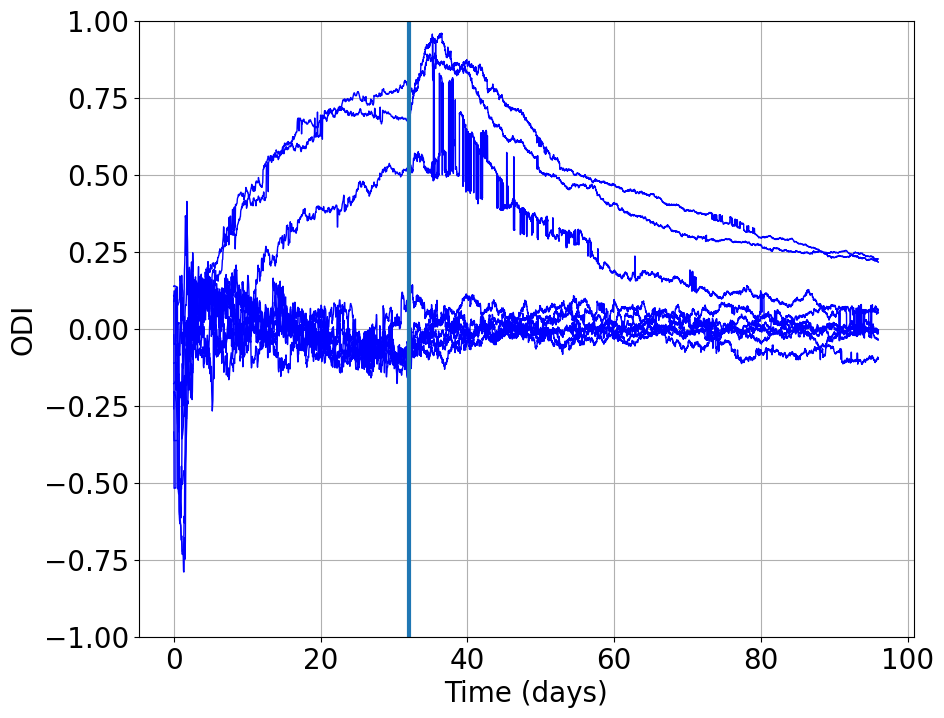

In [59]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

plot(R.t/day,R.ODI[:,:10],'b-',lw=1);

gca().set_ylim([-1,1])
ylim=gca().get_ylim()
vlines(R.sequence_times[1][0]/day,*ylim)

ylabel('ODI')
xlabel('Time (days)')

In [81]:
func=run_one_continuous_fix

p=Struct()
p.eta=eta
p.number_of_neurons=number_of_neurons
p.mu_c=7.5
p.sigma_c=2
p.mu_r=0
p.sigma_r=0
p.blur=[4,-1]
p.noise=(.1,.1)
p.eta=2e-6
p.total_time=[8*day*4,8*day*8]
p.sfname=base_sim_dir+f"/fix long mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"
print(p.sfname)


sims-2025-06-09 figs/fix long mu_c=7.5 sigma_c=2 blur=4.asdf


In [82]:
overwrite=True

In [83]:
if not os.path.exists(p.sfname) or overwrite:
    print("Running deficit/fix development")
    results = [func.remote(p,overwrite=True)]
    sfnames=ray.get(results)
else:
    sfnames=[p.sfname]

Running deficit/fix development


In [84]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

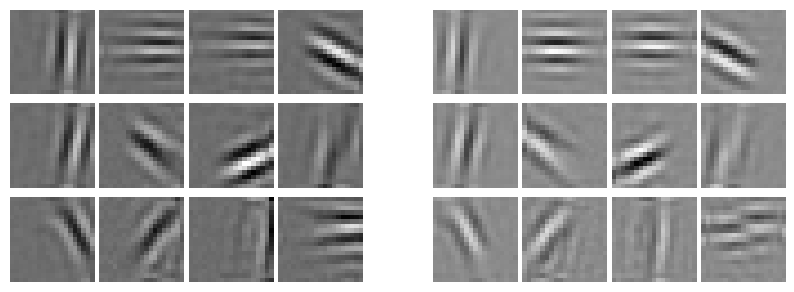

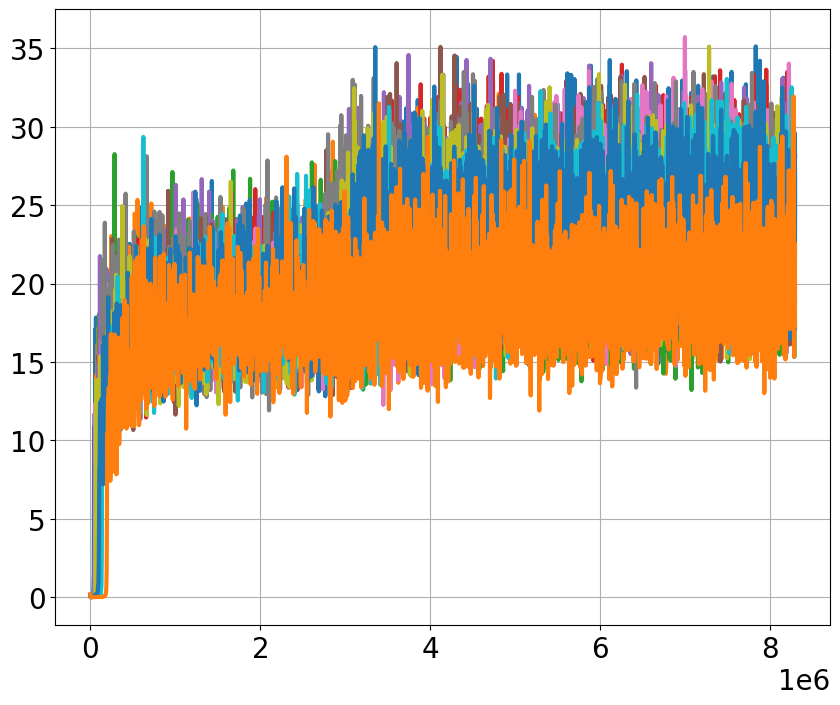

In [85]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [86]:
wim=R.weight_image(R.W[-1,::])
vmin,vmax=wim.min(),wim.max()
wim.shape

(12, 2, 19, 19)

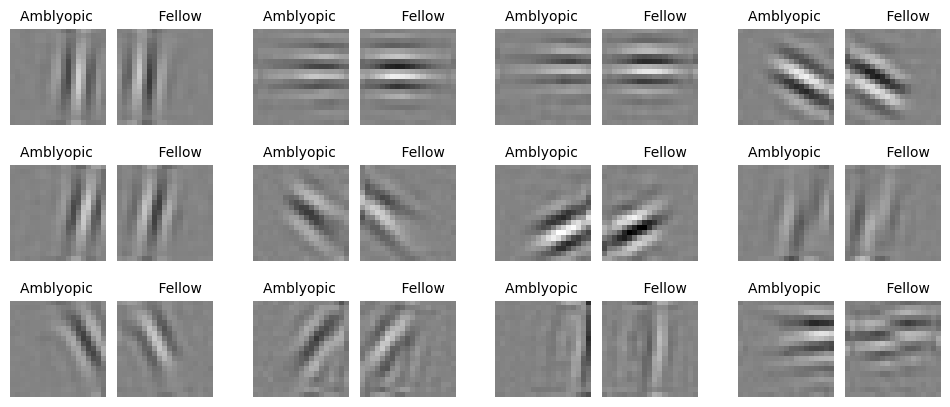

In [87]:
figure(figsize=(12,5))
for i in range(12):
    subplot(3,4,i+1)

    im=np.hstack((wim[i,0,:,:],vmax*ones((wim.shape[-1],2)),wim[i,1,:,:]))
    
    imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
    grid(None)
    title('Amblyopic               Fellow',size=10)
    axis('off')

(0.0, 77.43413531394341)

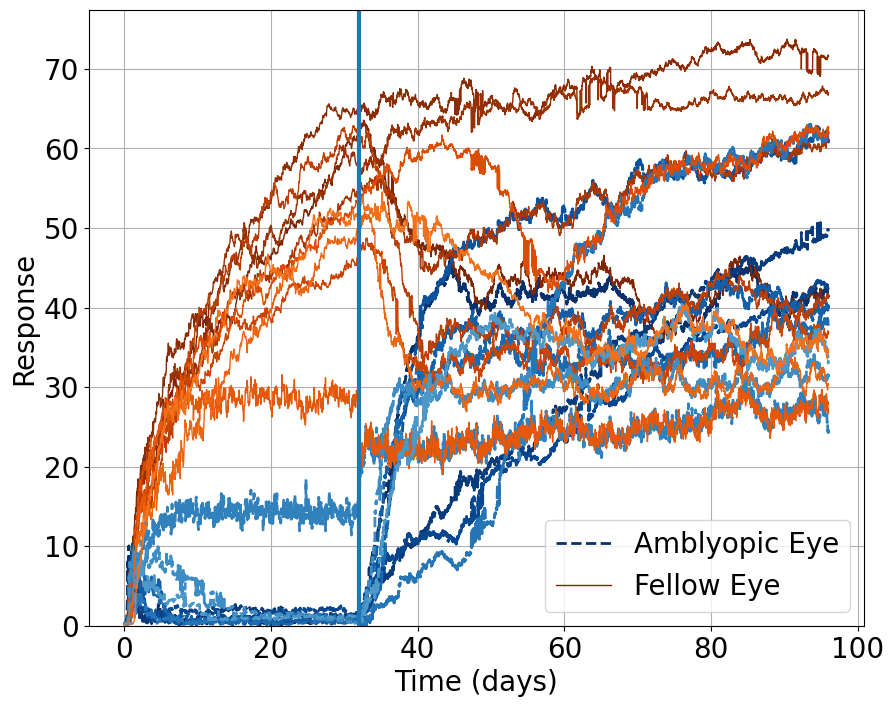

In [88]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

for n in range(10):

    if n==0:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]),label='Amblyopic Eye');
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]),label='Fellow Eye');
    else:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]));
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]));


ylabel('Response')
xlabel('Time (days)')
legend()

ylim=gca().get_ylim()
ylim=[0,ylim[1]]
vlines(R.sequence_times[1][0]/day,*ylim)
gca().set_ylim(ylim)


Text(0.5, 0, 'Time (days)')

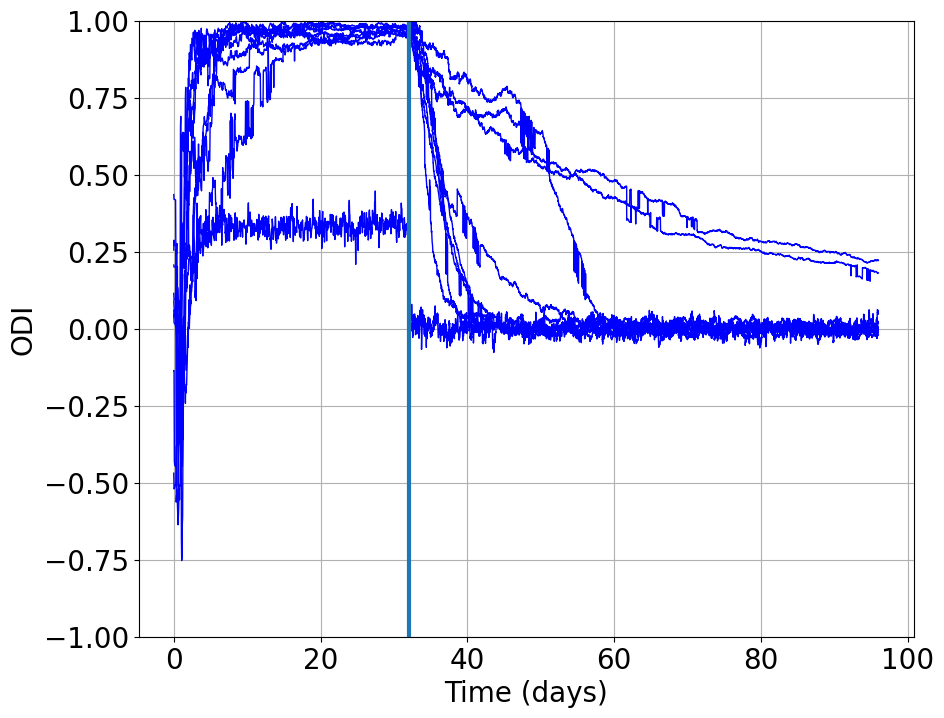

In [89]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

plot(R.t/day,R.ODI[:,:10],'b-',lw=1);

gca().set_ylim([-1,1])
ylim=gca().get_ylim()
vlines(R.sequence_times[1][0]/day,*ylim)

ylabel('ODI')
xlabel('Time (days)')

why does increasing the variability wipe out the deficit?